Loading Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.utils import shuffle
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from geopy.distance import geodesic

Understanding the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print('This is the start of my data science project')
df = pd.read_csv('/content/drive/MyDrive/fraudTrain.csv',index_col=0)
df.head()

This is the start of my data science project


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop               

from the data above we realise that there are no missing values. The datatypes are a combination of integers, float and objects.

In [ ]:
df.isnull().sum()

,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0
city,0


In [ ]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

In [ ]:
df.is_fraud.value_counts()


,count
is_fraud,
0,1289169
1,7506


From the data above we have 1289169 non fradulent transactions and 7506 fradulent transactions. Below we realise only 0.578865 transactions are fradulent

In [ ]:
df.is_fraud.value_counts(normalize=True)*100

,proportion
is_fraud,
0,99.421135
1,0.578865


Lets first convert this to the right data frames

In [ ]:
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')
df['age'] = (pd.to_datetime('today') - df['dob']).dt.days // 365


In [ ]:
df['transaction_hour'] = pd.to_datetime(df['trans_date_trans_time']).dt.hour
df['transaction_day'] = pd.to_datetime(df['trans_date_trans_time']).dt.dayofweek
df['transaction_day_name'] = pd.to_datetime(df['trans_date_trans_time']).dt.day_name()
df['distance'] = df.apply(lambda x: geodesic((x['lat'], x['long']), (x['merch_lat'], x['merch_long'])).km, axis=1)

This extracts the hour,day of the week and month from the column trans_date_trans_time.
We can also get the exact age of the people who transacted from the dob

Lets explore our data further using visualizations

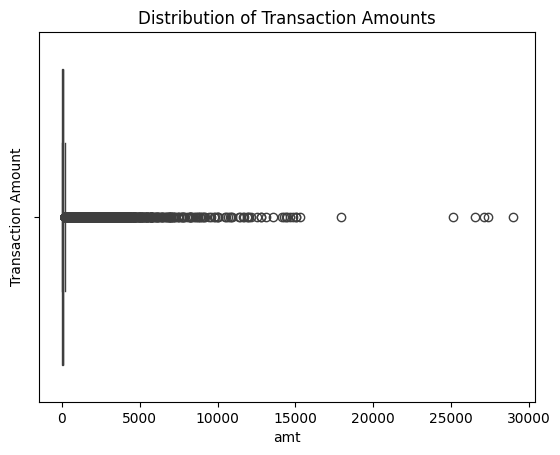

In [ ]:
#For 'amt' column (amount of the transaction)
sns.boxplot(x=df['amt'])
plt.ylabel("Transaction Amount")
plt.title("Distribution of Transaction Amounts")
plt.show()




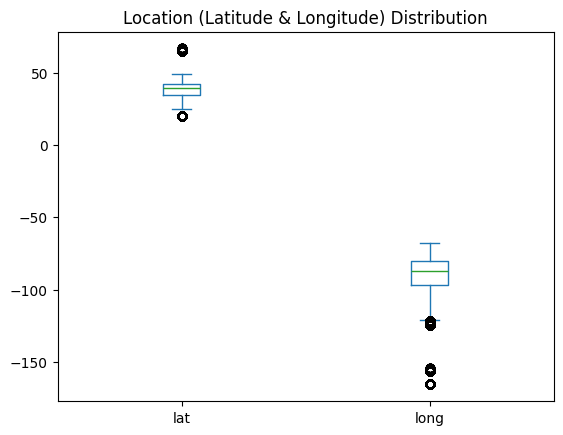

In [ ]:
# For 'lat' and 'long' columns (location coordinates)
df[['lat', 'long']].plot(kind='box')
plt.title("Location (Latitude & Longitude) Distribution")
plt.show()

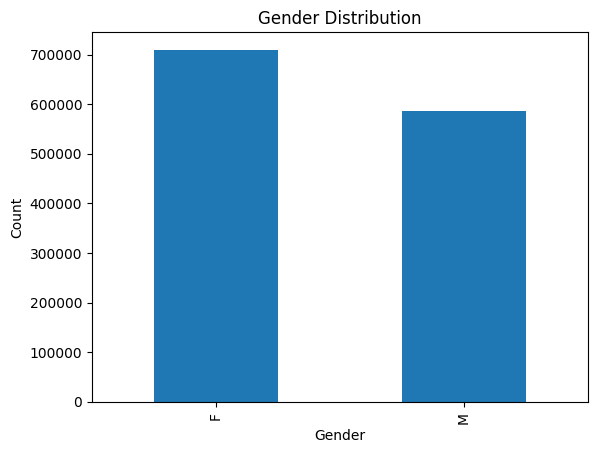

In [ ]:

# For 'gender' column
df['gender'].value_counts().plot(kind='bar')
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender Distribution")
plt.show()

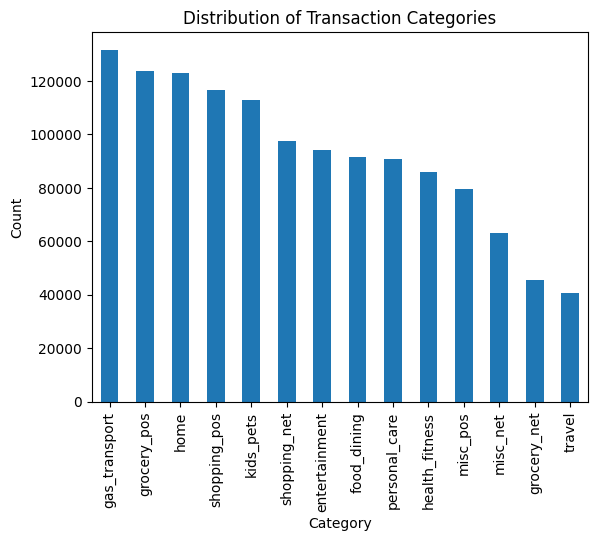

In [ ]:
df['category'].value_counts().plot(kind='bar')
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Distribution of Transaction Categories")
plt.show()


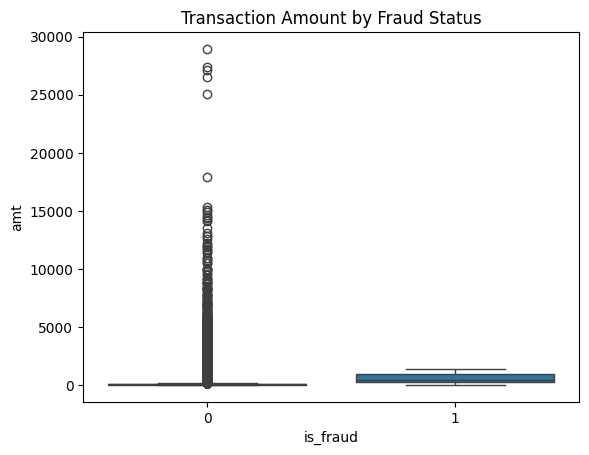

In [ ]:

sns.boxplot(x='is_fraud', y='amt', data=df)
plt.title("Transaction Amount by Fraud Status")
plt.show()


Most of the fradulent transactions are certainly below 5000

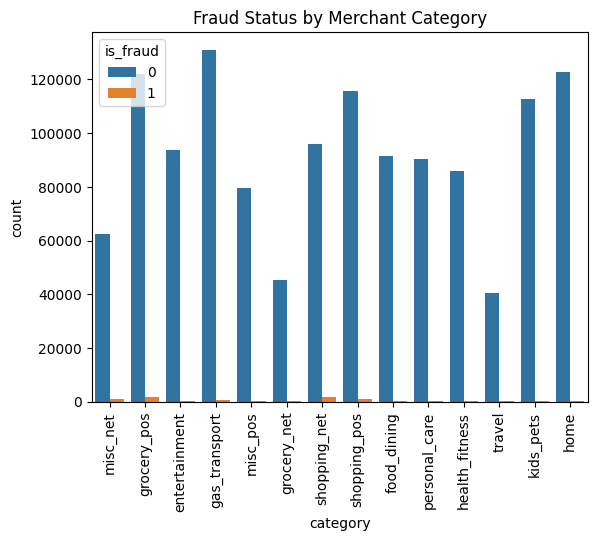

In [ ]:
sns.countplot(x='category', hue='is_fraud', data=df)
plt.title("Fraud Status by Merchant Category")
plt.xticks(rotation=90)
plt.show()


the bar plot shows us which category had higher number of fradulent transactions

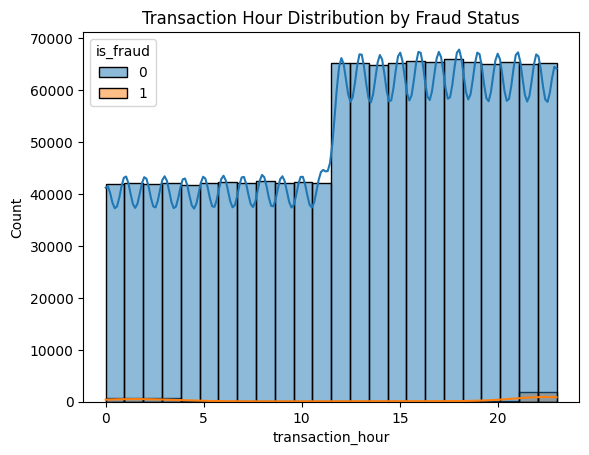

In [ ]:
sns.histplot(data=df, x='transaction_hour', hue='is_fraud', bins=24, kde=True)
plt.title("Transaction Hour Distribution by Fraud Status")
plt.show()


we see that fraud rates were more at particulat times of the day. We can also do an analysis for the day of the week.

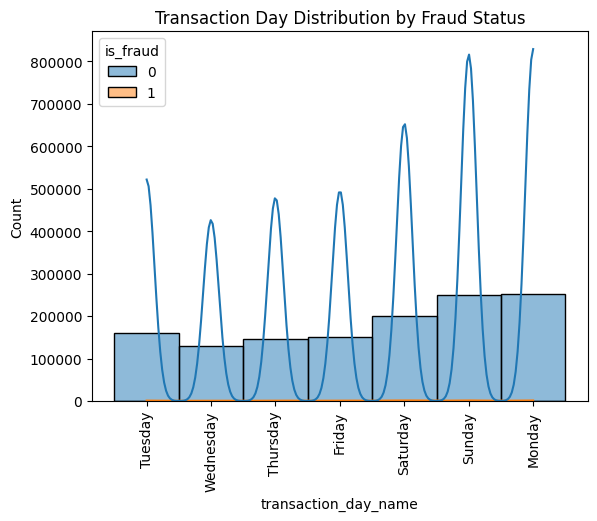

In [ ]:

sns.histplot(data=df, x='transaction_day_name', hue='is_fraud', bins=20, kde=True)
plt.title("Transaction Day Distribution by Fraud Status")
plt.xticks(rotation=90)
plt.show()


we can also check for the correlation of distances between cardholder location and merchant location

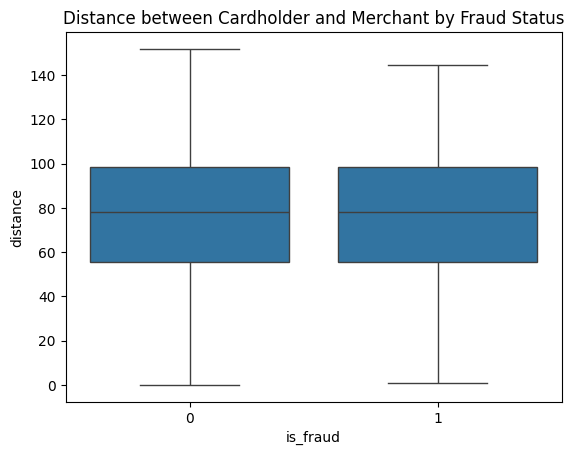

In [ ]:
sns.boxplot(x='is_fraud', y='distance', data=df)
plt.title("Distance between Cardholder and Merchant by Fraud Status")
plt.show()

From the boxplot we see there is no significant differences between the distances of fradulent and non fradulent transactions. The location might therefore not be a significant variable in determining if transactions are fradulent or not.

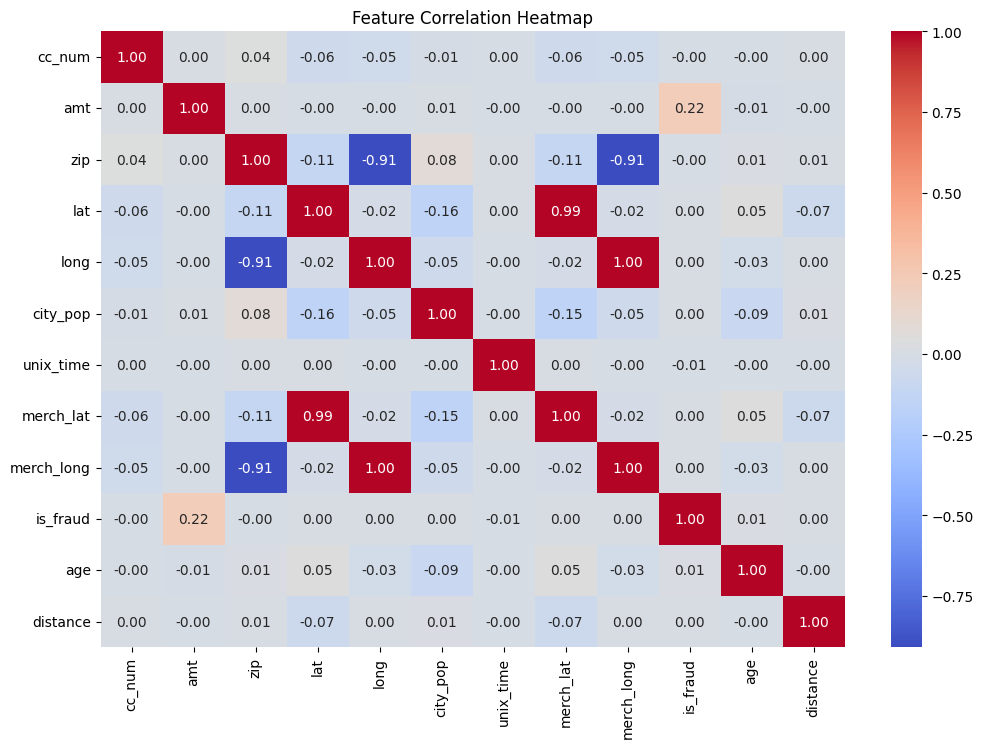

In [ ]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()


plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()



from the above heatmap we see that the most significant correlation is the amount and is_fraud columns

Data cleaning

Lets remove the outliers we have in the amt column. For best result we will remove the outliers for fradulent tansactions separetly from those of non fradulent transactions.

In [ ]:
fraudulent = df[df['is_fraud'] == 1]
non_fraudulent = df[df['is_fraud'] == 0]

def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    filtered_data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return filtered_data

fraudulent_cleaned = remove_outliers_iqr(fraudulent, 'amt')
non_fraudulent_cleaned = remove_outliers_iqr(non_fraudulent, 'amt')

df_cleaned = pd.concat([fraudulent_cleaned, non_fraudulent_cleaned])

print(f"Original dataset size: {len(df)}")
print(f"Cleaned dataset size: {len(df_cleaned)}")

Original dataset size: 1296675
Cleaned dataset size: 1233903


In [ ]:
df_cleaned.is_fraud.value_counts()

,count
is_fraud,
0,1226397
1,7506


We won't need the `first`, `last`, and `cc_num` columns.Drop any columns that won't help with fraud detection

In [ ]:
df = df_cleaned.drop(columns=['first','last','cc_num','street', 'city', 'trans_num', 'trans_date_trans_time', 'dob','trans_date_trans_time'])

In [ ]:
df.columns

Index(['merchant', 'category', 'amt', 'gender', 'state', 'zip', 'lat', 'long',
       'city_pop', 'job', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud',
       'age', 'transaction_hour', 'transaction_day', 'transaction_day_name',
       'distance'],
      dtype='object')

Feature Engineering

Lets convert the categorical data into numerical data

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])


In [ ]:
df = pd.get_dummies(df, columns=['category','job','gender','merchant', 'state', 'transaction_day_name'], drop_first=True)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['amt', 'lat', 'long', 'city_pop', 'age', 'distance']] = scaler.fit_transform(df[['amt', 'lat', 'long', 'city_pop', 'age', 'distance']])


Lets check for multicolinearity in our variables

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_df = df.select_dtypes(include=[float, int])

vif = pd.DataFrame()
vif["Variable"] = numeric_df.columns
vif["VIF"] = [variance_inflation_factor(numeric_df.values, i) for i in range(numeric_df.shape[1])]

print(vif)


            Variable          VIF
0                amt     1.515890
1                zip     6.396841
2                lat    69.633904
3               long   225.099297
4           city_pop     1.036592
5          unix_time  7986.191233
6          merch_lat    69.355485
7         merch_long   221.136062
8           is_fraud     1.506030
9                age     1.042398
10  transaction_hour     1.043590
11   transaction_day     1.000521
12          distance     1.005197


From the result we can say the variables merch_long & long have multicollineriality, unix_time is redudant and the rest have no multicolinearity.
Hence lets drop the column unix_time. We will also drop the Merch_long which is correlated to long, merch lat is correlated to lat and the zip column

In [ ]:
df = df.drop(columns=['unix_time'])
df = df.drop(columns=['merch_long','merch_lat','zip'])

lets confirm we now only have variables with no multicolinearity

In [ ]:
numeric_df = df.select_dtypes(include=[float, int])

vif = pd.DataFrame()
vif["Variable"] = numeric_df.columns
vif["VIF"] = [variance_inflation_factor(numeric_df.values, i) for i in range(numeric_df.shape[1])]

print(vif)

           Variable       VIF
0               amt  1.510069
1               lat  1.031519
2              long  1.004739
3          city_pop  1.036050
4          is_fraud  1.514488
5               age  1.023410
6  transaction_hour  2.115809
7   transaction_day  2.081581
8          distance  1.005181


Model Building

In [ ]:
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']
# Convert categorical columns to numeric
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(len(X_train), len(X_test))
print(len(y_train), len(y_test))

# Ensure X_train and X_test have the same columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

987122 246781
987122 246781


As observed throughtout the dataset our data for fraudulent transactions is not equal. Using the dataset as is might lead to incorrect predictions as the model would have been over trained on a particular set of data and undertrained on the other. We therefore have two options Oversampling and undersampling.

**Undersampling** non fraud

fraudulent We will use the undersampling method.This ensures our dataset has less non-fraudulent rows to match that of the fraudulent transactions

In [ ]:
df = df.sample(frac=1)
fraud = df.loc[df.is_fraud == 1]
non_fraud = df.loc[df.is_fraud == 0][:len(fraud)]
undersampled_df = pd.concat([fraud, non_fraud]).sample(frac=1, random_state=42)
undersampled_df.head()

,amt,lat,long,city_pop,is_fraud,age,transaction_hour,transaction_day,distance,category_food_dining,...,state_WA,state_WI,state_WV,state_WY,transaction_day_name_Monday,transaction_day_name_Saturday,transaction_day_name_Sunday,transaction_day_name_Thursday,transaction_day_name_Tuesday,transaction_day_name_Wednesday
189498,3.916302,0.599845,-0.248760,0.457038,1,-0.448446,2,0,-0.038513,False,...,False,False,False,False,True,False,False,False,False,False
719981,13.151763,-0.725711,-0.040359,-0.291309,1,0.581704,16,6,0.255894,False,...,False,False,False,False,False,False,True,False,False,False
342742,0.808295,-0.496927,0.448696,-0.206452,0,0.238321,13,0,-0.226610,True,...,False,False,False,False,True,False,False,False,False,False
827432,0.215649,-1.642131,-0.045950,-0.258176,0,-0.219523,22,0,-0.816803,False,...,False,False,False,False,True,False,False,False,False,False
542095,2.841591,0.114184,-0.300998,0.122775,1,-1.077981,23,0,-1.756646,False,...,False,False,False,False,True,False,False,False,False,False


This code randomly selects rows, it also ensures the number of rows of non-fraudelent transactions are equal to those of fraudelent transactions.

In [ ]:
undersampled_df.is_fraud.value_counts()

,count
is_fraud,
1,7506
0,7506


In [ ]:
X = undersampled_df.drop('is_fraud', axis=1)
y = undersampled_df['is_fraud']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Model Evaluation

We are doing binary classification. Logistics regression works best but just to be sure we will try different models.

First lets put the various methods we would like to use in a dictionary. Instead of calling the methods we can use the dictionary.

In [ ]:
classifiers = {
    "LogisiticRegression": LogisticRegression(max_iter=1000),
    "KNearest": KNeighborsClassifier(),
    "Support Vector Classifier": SVC(max_iter=1000),
    "DecisionTreeClassifier": DecisionTreeClassifier()
}

Classification Report

The for loop, loops through the dictionary and performs acuracy scores for each of the models. It then gives us the best model and its accuarcy after comparing all models.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

results = {}

for name, classifier in classifiers.items():
    # Train the model
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)

    # Evaluate performance
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc}")
    print(classification_report(y_test, y_pred))

# Identify the best model
best_model = max(results, key=results.get)
print("Best Model:", best_model, "with Accuracy:", results[best_model])


LogisiticRegression Accuracy: 0.8484848484848485
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1508
           1       0.89      0.80      0.84      1495

    accuracy                           0.85      3003
   macro avg       0.85      0.85      0.85      3003
weighted avg       0.85      0.85      0.85      3003

KNearest Accuracy: 0.9097569097569097
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      1508
           1       0.91      0.90      0.91      1495

    accuracy                           0.91      3003
   macro avg       0.91      0.91      0.91      3003
weighted avg       0.91      0.91      0.91      3003



/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Support Vector Classifier Accuracy: 0.48917748917748916
              precision    recall  f1-score   support

           0       0.48      0.27      0.35      1508
           1       0.49      0.71      0.58      1495

    accuracy                           0.49      3003
   macro avg       0.49      0.49      0.46      3003
weighted avg       0.49      0.49      0.46      3003

DecisionTreeClassifier Accuracy: 0.9726939726939727
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1508
           1       0.97      0.97      0.97      1495

    accuracy                           0.97      3003
   macro avg       0.97      0.97      0.97      3003
weighted avg       0.97      0.97      0.97      3003

Best Model: DecisionTreeClassifier with Accuracy: 0.9726939726939727


From the above result we realise KNearest and Decision trees have the highest accuracy. I would like to explore the logistic regression and decision tree further to help me choose the best fit model for the best results.


Hyperparameter tuning

Lets get the best parameters for the decision tree and logistic regression models

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Decision Tree Classifier
tree_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": list(range(2, 5)),
    "min_samples_leaf": list(range(5, 8)),
}
grid_tree = GridSearchCV(DecisionTreeClassifier(), tree_params, cv=5, scoring='accuracy')
grid_tree.fit(X_train, y_train)

# Best Decision Tree Classifier
tree_clf = grid_tree.best_estimator_

# Logistic Regression
log_reg_params = {
    "penalty": ['l1', 'l2'],
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "solver": ['liblinear'],  # 'liblinear' supports both L1 and L2
}
grid_log_reg = GridSearchCV(LogisticRegression(max_iter=1000), log_reg_params, cv=5, scoring='accuracy')
grid_log_reg.fit(X_train, y_train)

# Best Logistic Regression
log_reg = grid_log_reg.best_estimator_

# Display best parameters for each model
print("Best Parameters for Decision Tree:", grid_tree.best_params_)
print("Best Parameters for Logistic Regression:", grid_log_reg.best_params_)





/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Parameters for Decision Tree: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 5}
Best Parameters for Logistic Regression: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}


The Decision Tree has been regularized with constraints on depth and minimum samples, ensuring it avoids overfitting while maintaining interpretability.
The Logistic Regression model is simplified with strong regularization (C: 0.01), emphasizing sparsity (L1 penalty) to focus on the most critical predictors. This combination improves robustness and generalization.

Confusion Matrix

Lets use a confusion matrix t help us understand the models even further.

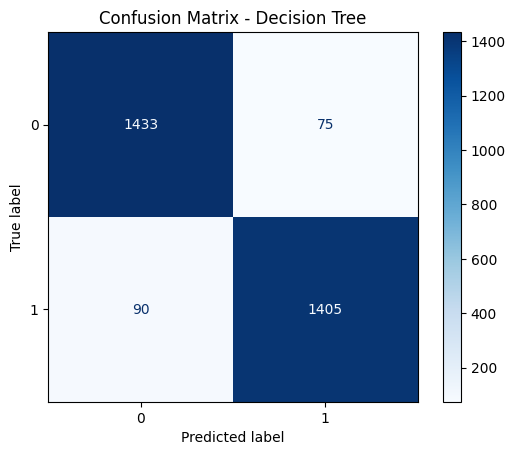

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate predictions for the Decision Tree model
y_pred_tree = tree_clf.predict(X_test)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred_tree)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tree_clf.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

Our decision tree predicted TP-1387,TN-1435,FP-73,FN-108. This means the model accurately predicted 1387 fraudelent transactions, 1435 non-fraudelent transactions. It  predicted 108 fraudelent transactions as non fraudelent and 73 non- fraudelent transactions as fraudelent.



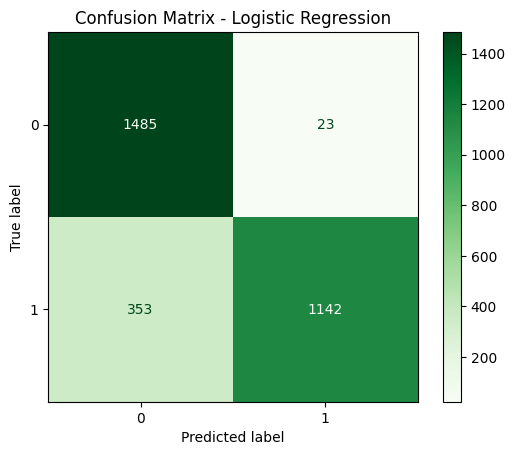

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions for the Logistic Regression model
y_pred_log_reg = log_reg.predict(X_test)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred_log_reg)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_)
disp.plot(cmap='Greens', values_format='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


Our decision tree predicted TP-1128, TN-1465, FN-367, FP-43.his means the model accurately predicted 1128 fraudelent transactions, 1465 non-fraudelent transactions. It  predicted 367 fraudelent transactions as non fraudelent and 43 non- fraudelent transactions as fraudelent.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# For Decision Tree
print("Decision Tree Model Performance:")
y_pred_tree = tree_clf.predict(X_test)  # Replace 'tree_clf' with your Decision Tree model variable

# Calculate and print metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_tree):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_tree):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred_tree):.2f}")

# For Logistic Regression
print("\nLogistic Regression Model Performance:")
y_pred_log = log_reg.predict(X_test)  # Replace 'log_reg' with your Logistic Regression model variable

# Calculate and print metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_log):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_log):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred_log):.2f}")



Decision Tree Model Performance:
Accuracy: 0.95
Precision: 0.95
Recall: 0.94
F1-Score: 0.94

Logistic Regression Model Performance:
Accuracy: 0.87
Precision: 0.98
Recall: 0.76
F1-Score: 0.86


The decision tree has a higher recall of 93% as compared to 75% from the logistics regresion. This is what also resulted in the lower FN of the decision tree of 108 compared to that of logistics regression of 367. The decision tree also has a higher F1 score of 94% while logistics regression has 85%.

ROC Curve

We can also usee an ROC curve to compare the performance of the two models. AUC stands for the Area under the curve with  1 being a perfect model and 0.5 a random guess.

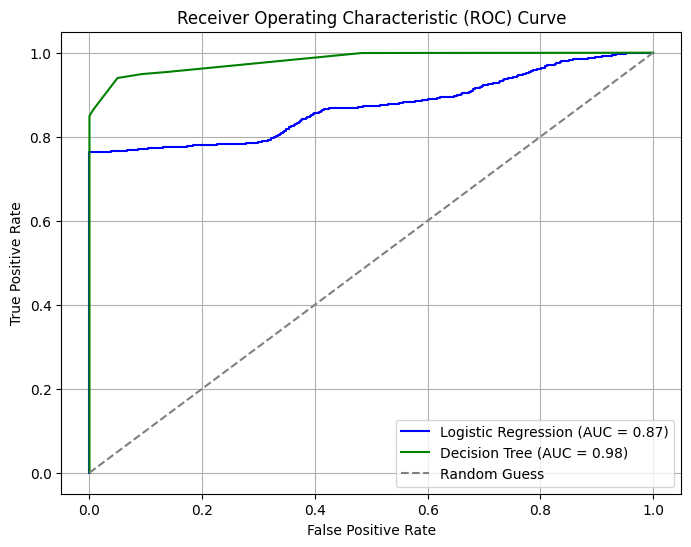

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Logistic Regression predictions
y_pred_prob_logreg = log_reg.predict_proba(X_test)[:, 1]  # Use your logistic regression model
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_pred_prob_logreg)
roc_auc_logreg = auc(fpr_logreg, tpr_logreg)

# Decision Tree predictions
y_pred_prob_tree = tree_clf.predict_proba(X_test)[:, 1]  # Use your decision tree model
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_pred_prob_tree)
roc_auc_tree = auc(fpr_tree, tpr_tree)

# Plot the ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, color='blue', label=f'Logistic Regression (AUC = {roc_auc_logreg:.2f})')
plt.plot(fpr_tree, tpr_tree, color='green', label=f'Decision Tree (AUC = {roc_auc_tree:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()



Decision Tree outperforms Logistic Regression because its curve is closer to the top-left corner and has a higher AUC (0.98 vs. 0.87).

Learning curve

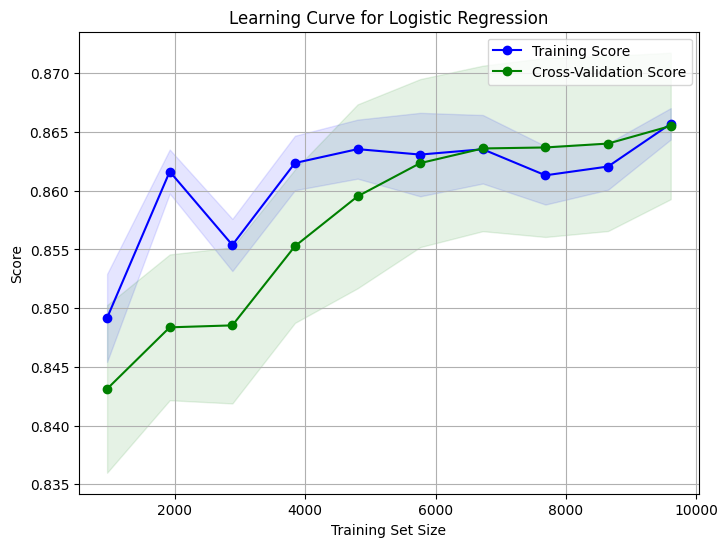

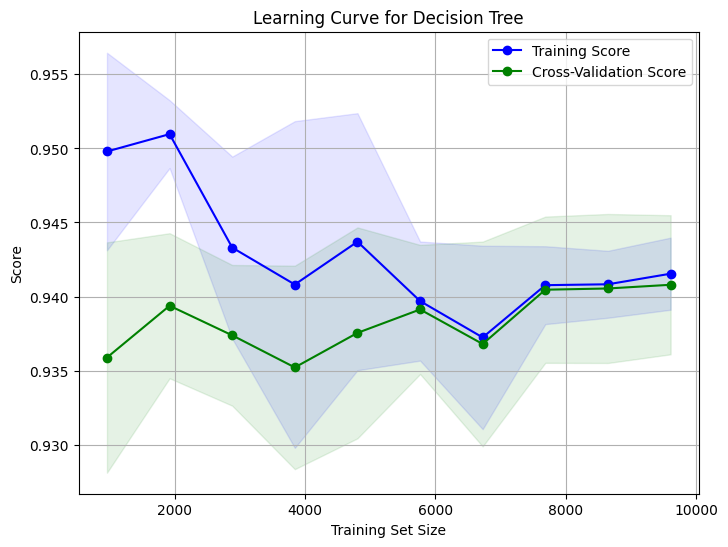

In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Function to plot learning curve
def plot_learning_curve(estimator, X, y, title="Learning Curve", cv=5, scoring='accuracy'):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Score")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
    plt.plot(train_sizes, test_mean, 'o-', color="green", label="Cross-Validation Score")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="green")

    plt.title(title)
    plt.xlabel("Training Set Size")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Example usage for Logistic Regression
plot_learning_curve(log_reg, X_train, y_train, title="Learning Curve for Logistic Regression")

# Example usage for Decision Tree
plot_learning_curve(tree_clf, X_train, y_train, title="Learning Curve for Decision Tree")


For the logistic regresion.The training score is consistently high around 0.87, indicating the model performs very well on the training data.
The cross-validation score starts lower around 0.83 but improves as the training data increases, eventually converging with the training score.
Initially, there is a noticeable gap between the training and validation scores. However, as the dataset size increases, the gap narrows meaning  its benefiting from more data and mitigating overfitting.
The learning curve suggests that the model generalizes reasonably well when trained on a larger dataset, as the validation score converges toward the training score.However the gap  indicates some level of overfitting.

For the decision tree.The training score starts high 0.95 and remains consistent as the training data increases.
The cross-validation score starts lower but improves as the training data increases, approaching the training score. Showing better generalization with larger datasets.
The gap between the training and validation scores is minimal as the data size increases, suggesting that the Decision Tree is generalizing well to unseen data.
While the model benefits from more data, the plateau suggests that increasing the dataset size further might not yield significant improvements.

I have therefore picked the decision tree as the best model for my model. Leys refit it for the whole dataset

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Step 1: Instantiate the Decision Tree model with the best hyperparameters
final_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)

# Step 2: Fit the model on the entire dataset
final_model.fit(X, y)  # Replace X and y with your full dataset of features and target

print("Decision Tree has been successfully refitted on the full dataset!")


Decision Tree has been successfully refitted on the full dataset!


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Step 1: Predict on the entire dataset
y_pred = final_model.predict(X)
y_pred_proba = final_model.predict_proba(X)[:, 1]  # Probability scores for the positive class

# Step 2: Calculate performance metrics
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
auc = roc_auc_score(y, y_pred_proba)

print("Evaluation Metrics for the Final Decision Tree Model:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"AUC-ROC: {auc:.2f}")


Evaluation Metrics for the Final Decision Tree Model:
Accuracy: 0.94
Precision: 0.95
Recall: 0.94
F1 Score: 0.94
AUC-ROC: 0.98


<ipython-input-51-e3670a5d649e>:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


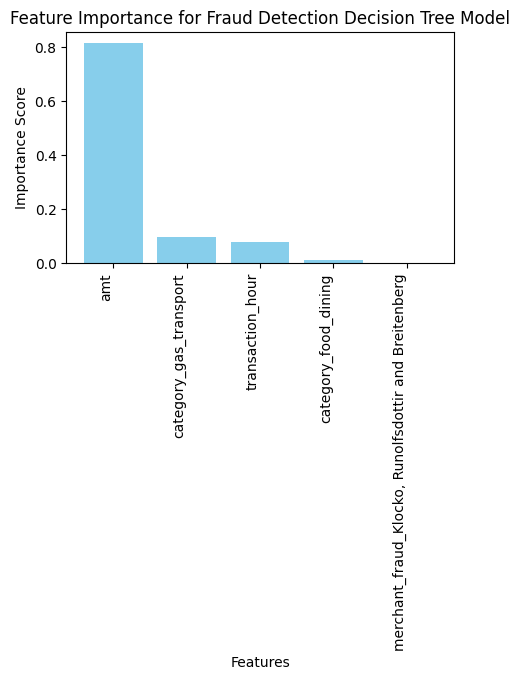

In [ ]:
feature_importance = final_model.feature_importances_

# Get feature importances and sort them
importances = final_model.feature_importances_
feature_names = X.columns
feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Plot the top N features
top_n = 5  # Change this to display more or fewer features
top_features = feature_importances.head(top_n)

plt.figure(figsize=(5, 3))
plt.bar(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.xticks(rotation=90, ha='right')
plt.title('Feature Importance for Fraud Detection Decision Tree Model')
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.tight_layout()
plt.show()


##Conclusion##
###Challenges Faced###
Imbalanced dataset (fraudulent cases were rare).
Data quality issues (outliers).
###Recommendations for Improvement###
Continuous Improvement: Periodically retrain the model with new data to adapt to evolving fraud patterns..
Enhance Dataset: Collect more transactional data, especially fraudulent cases.
Advanced Techniques: Try ensemble models
Handle Imbalance: Use different techniques like oversampling to check for better dataset balancing .
###Importance###
Advancement in technology is also modifying a lot of sectors and people are embracing technology more. This has made online transactions even more famous. With such advancements credit card fraud detection is extremely important.
In Kenya for example there has been a rise in activities like carding. Developing a machine learning model capable of real-time fraud detection and seamless integration into financial systems could significantly reduce fraud instances
